NOMBRE: ALEJANDRO JOSE GOMEZ HERNANDEZ


CARNE: 20347


FECHA: 22/09/2024

Responda las siguientes preguntas:
1. ¿Cuáles son los dos procesos principales de un transformer y qué función cumplen?
  

*   A. Encoder:
Toma una secuencia de entrada, y la vuelve en una representación vectorial interna. Usando Self-Attention, que deja que cada token de la secuencia se relacione con los demás, capturando contexto y dependencias entre palabras. Luego, con una Red Neuronal Feedforward procesa la info. Así de esta forma ya puede tener representaciones más profundas y abstractas de la secuencia. Su función es generar una representación rica y compleja de los datos de entrada que pueda ser utilizada por el Decoder para tareas posteriores.

*   B. Decoder
Toma la representación generada por Encoder y la vuelve una secuencia de salida, ya sea una traducción o predicción etc. Usa una máscara que impide al modelo acceder a futuros tokens durante la generación de la secuencia. También agrega Attention Encoder-Decoder, para usar la info del Encoder en la salida. La Red Neuronal Feedforward y refinar predicciones. Siendo esta su función.


  
2. Asigne cada uno de las siguientes subtareas a su proceso correspondiente(A o B): Multi-Head Self-Attention Mechanism,Position-wise Feed-Forward Networks,Masked Multi-Head Self-Attention Mechanism, Encoder-Decoder Multi-Head Attention,Position-wise Feed-Forward Networks

Después de asignar, explique la función de cada una de las partes. Luego, proceda a programar un transformer con cada una de esas partes utilizando solo tensorflow o Pytorch.

----------

A (Encoder):
   - Multi-Head Self-Attention Mechanism
   - Position-wise Feed-Forward Networks

B (Decoder):
   - Masked Multi-Head Self-Attention Mechanism
   - Encoder-Decoder Multi-Head Attention
   - Position-wise Feed-Forward Networks

   Multi-Head Self-Attention Mechanism (A): Permite al encoder analizar las relaciones entre los tokens de la secuencia de entrada, proporcionando un contexto más rico al evaluar cómo cada token se relaciona con los demás.

Position-wise Feed-Forward Networks (A y B): Estas redes neuronales aplican transformaciones independientes a cada token, permitiendo que el modelo capture representaciones más profundas y complejas de los datos, tanto en el encoder como en el decoder.

Masked Multi-Head Self-Attention Mechanism (B): Similar al mecanismo del encoder, pero con una máscara que impide que el modelo acceda a tokens futuros durante la generación de la secuencia, asegurando que las predicciones sean secuenciales y no anticipadas.

Encoder-Decoder Multi-Head Attention (B): Facilita que el decoder utilice la información generada por el encoder, conectando las representaciones de entrada con la salida que el modelo está generando, mejorando la precisión en la predicción.




In [2]:
!pip install torch torchvision torchaudio


In [3]:
import numpy as np
def positional_encoding(position, d_model):
    angle_rads = np.arange(position)[:, np.newaxis] / np.power(10000, (2 * (np.arange(d_model) // 2)) / np.float32(d_model))
    angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
    angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])
    return torch.tensor(angle_rads[np.newaxis, ...], dtype=torch.float32)

In [4]:
import torch
import torch.nn as nn
import numpy as np
import re

def positional_encoding(position, d_model):
    angle_rads = np.arange(position)[:, np.newaxis] / np.power(10000, (2 * (np.arange(d_model) // 2)) / np.float32(d_model))
    angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
    angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])
    return torch.tensor(angle_rads[np.newaxis, ...], dtype=torch.float32)


Voy a usar esta frase de Chomsky:
"Capitalism is a system in which the central institutions of society are, in principle, under autocratic control. Thus, a corporation or an industry is, if we were to think of it in political terms, fascist, that is, it has tight control at the top and strict obedience has to be established at every level. Just as I'm opposed to political fascism, I am opposed to economic fascism. I think that until the major institutions of society are under the popular control of participants and communities, it's pointless to talk about democracy."

In [5]:
!pip install torchtext


In [6]:
# Mecanismo de Multi-Head Self-Attention
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embed_size, heads):
        super(MultiHeadSelfAttention, self).__init__()
        self.embed_size = embed_size
        self.heads = heads
        self.head_dim = embed_size // heads

        assert self.head_dim * heads == embed_size, "Embed size must be divisible by heads"

        self.values = nn.Linear(self.head_dim, embed_size, bias=False)
        self.keys = nn.Linear(self.head_dim, embed_size, bias=False)
        self.queries = nn.Linear(self.head_dim, embed_size, bias=False)
        self.fc_out = nn.Linear(embed_size, embed_size)

    def forward(self, values, keys, query, mask):
        N = query.shape[0]
        value_len, key_len, query_len = values.shape[1], keys.shape[1], query.shape[1]

        # Split embedding into self.heads different pieces
        values = values.reshape(N, value_len, self.heads, self.head_dim)
        keys = keys.reshape(N, key_len, self.heads, self.head_dim)
        queries = query.reshape(N, query_len, self.heads, self.head_dim)

        # Calculate the scores
        energy = torch.einsum("nqhd,nkhd->nhqk", [queries, keys])

        if mask is not None:
            energy = energy.masked_fill(mask == 0, float("-1e20"))

        attention = torch.softmax(energy / (self.embed_size ** (1 / 2)), dim=3)

        out = torch.einsum("nhql,nlhd->nqhd", [attention, values]).reshape(
            N, query_len, self.embed_size
        )

        return self.fc_out(out)

In [7]:
# Redes Feed-Forward por token (Position-wise)
class PositionWiseFeedForward(nn.Module):
    def __init__(self, embed_size, forward_expansion):
        super(PositionWiseFeedForward, self).__init__()
        self.fc1 = nn.Linear(embed_size, forward_expansion * embed_size)
        self.fc2 = nn.Linear(forward_expansion * embed_size, embed_size)

    def forward(self, x):
        return self.fc2(torch.relu(self.fc1(x)))

In [8]:
# Bloque Encoder
class TransformerBlock(nn.Module):
    def __init__(self, embed_size, heads, forward_expansion, dropout):
        super(TransformerBlock, self).__init__()
        self.attention = MultiHeadSelfAttention(embed_size, heads)
        self.norm1 = nn.LayerNorm(embed_size)
        self.norm2 = nn.LayerNorm(embed_size)
        self.feed_forward = PositionWiseFeedForward(embed_size, forward_expansion)
        self.dropout = nn.Dropout(dropout)

    def forward(self, value, key, query, mask):
        attention = self.attention(value, key, query, mask)
        x = self.dropout(self.norm1(attention + query))
        forward = self.feed_forward(x)
        out = self.dropout(self.norm2(forward + x))
        return out


In [9]:
# Bloque Decoder
class DecoderBlock(nn.Module):
    def __init__(self, embed_size, heads, forward_expansion, dropout):
        super(DecoderBlock, self).__init__()
        self.attention = MultiHeadSelfAttention(embed_size, heads)
        self.norm = nn.LayerNorm(embed_size)
        self.transformer_block = TransformerBlock(embed_size, heads, forward_expansion, dropout)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, value, key, src_mask, trg_mask):
        attention = self.attention(x, x, x, trg_mask)
        query = self.dropout(self.norm(attention + x))
        out = self.transformer_block(value, key, query, src_mask)
        return out

In [10]:
# Transformer completo
class Transformer(nn.Module):
    def __init__(self, embed_size, num_layers, heads, forward_expansion, dropout, vocab_size, max_length=1000):
        super(Transformer, self).__init__()
        self.embed_size = embed_size
        self.word_embedding = nn.Embedding(vocab_size, embed_size)
        self.position_embedding = positional_encoding(max_length, embed_size)  # Usar positional encoding

        self.layers = nn.ModuleList(
            [
                TransformerBlock(embed_size, heads, forward_expansion, dropout)
                for _ in range(num_layers)
            ]
        )
        self.fc_out = nn.Linear(embed_size, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask):
        N, seq_length = x.shape

        # Obtener embeddings de palabras y sumar el positional encoding
        word_embeddings = self.word_embedding(x)
        position_embeddings = self.position_embedding[:, :seq_length, :].to(x.device)  # Ajustar el encoding a la longitud de secuencia
        out = self.dropout(word_embeddings + position_embeddings)  # Sumar embeddings posicionales

        for layer in self.layers:
            out = layer(out, out, out, mask)

        return self.fc_out(out)

In [11]:
# Máscara para el decoder
def create_mask(src, trg):
    src_mask = (src != 0).unsqueeze(1).unsqueeze(2)
    trg_pad_mask = (trg != 0).unsqueeze(1).unsqueeze(2)
    trg_len = trg.shape[1]
    trg_sub_mask = torch.tril(torch.ones((trg_len, trg_len))).bool().to(trg.device)
    trg_mask = trg_pad_mask & trg_sub_mask
    return src_mask, trg_mask

In [12]:
# Función de tokenización
def simple_tokenizer(text):
    return re.findall(r'\b\w+\b', text.lower())

In [13]:
# Probar el transformer con la frase original
sentence = """Capitalism is a system in which the central institutions of society
are, in principle, under autocratic control. Thus, a corporation or an industry is,
if we were to think of it in political terms, fascist, that is, it has tight control
at the top and strict obedience has to be established at every level. Just as I'm
opposed to political fascism, I am opposed to economic fascism. I think that until
the major institutions of society are under the popular control of participants and
communities, it's pointless to talk about democracy."""

# Tokenización de la frase
tokens = simple_tokenizer(sentence)

# Crear un vocabulario simple
vocab = {word: i for i, word in enumerate(set(tokens), start=1)}
vocab_size = len(vocab) + 1  # +1 para el token de padding

# Convertir tokens en índices
indexed_sentence = [vocab[word] for word in tokens]

# Convertir a tensor
input_tensor = torch.tensor(indexed_sentence).unsqueeze(0)  # Añadir dimensión batch

# Máscara simple (sin padding en este caso)
src_mask = (input_tensor != 0).unsqueeze(1).unsqueeze(2)

In [14]:
# Parámetros de prueba
num_layers = 4
d_model = 128
num_heads = 8
dff = 512
input_vocab_size = 8500
target_vocab_size = 8000
pe_input = 1000
pe_target = 1000
dropout_rate = 0.1

# Instanciar el transformer con los datos de prueba
model = Transformer(d_model, num_layers, num_heads, dff, dropout_rate, input_vocab_size)

# Probar el modelo con una secuencia de longitud fija (batch=64, secuencia=50)
input_batch = torch.randint(0, input_vocab_size, (64, 50))  # Datos aleatorios
output = model(input_batch, None)

# Mostrar el resultado
print(output.shape)
print(output)

torch.Size([64, 50, 8500])
tensor([[[-1.1670, -0.1557,  1.3596,  ...,  0.0921, -0.4225,  0.6870],
         [-0.7603,  0.2564,  0.2089,  ..., -0.3947,  1.0691, -0.0162],
         [ 0.2874, -0.1682,  0.1900,  ...,  0.0404, -0.0695,  0.4609],
         ...,
         [-0.2813,  0.1297,  0.8402,  ..., -0.8626, -0.9164,  0.9055],
         [-0.0567, -0.7498, -0.2153,  ..., -0.6157, -0.3156,  1.1285],
         [-0.2027,  0.2136,  0.7138,  ..., -0.2369, -0.7498,  1.7090]],

        [[-0.2707, -0.7885,  0.6689,  ...,  0.5657, -0.2079,  0.0080],
         [ 0.3049,  0.4349,  1.5011,  ...,  0.5848, -0.3684,  1.3390],
         [ 0.5052, -0.0232,  0.0231,  ..., -0.3052, -0.0227, -0.4108],
         ...,
         [ 0.8201, -0.1242,  1.2114,  ...,  0.1574, -0.0045,  0.8544],
         [-0.1690,  0.1172,  0.2556,  ..., -1.3056, -0.6516,  0.3196],
         [-0.1352,  0.4253,  0.5136,  ..., -0.8655, -0.4513,  0.7573]],

        [[ 0.6498, -1.1441,  1.0232,  ...,  0.5751, -1.1730,  0.0846],
         [ 0.3190,

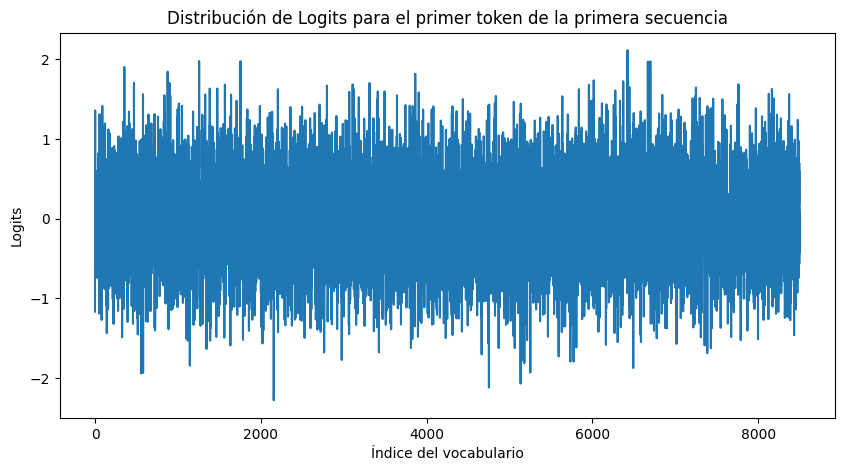

In [15]:
import matplotlib.pyplot as plt

logits = output[0, 0].detach().numpy()

plt.figure(figsize=(10, 5))
plt.plot(logits)
plt.title('Distribución de Logits para el primer token de la primera secuencia')
plt.xlabel('Índice del vocabulario')
plt.ylabel('Logits')
plt.show()


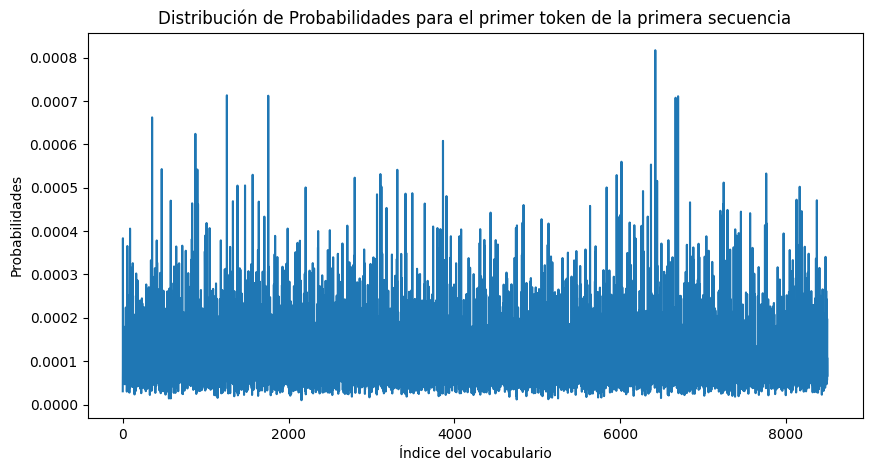

In [16]:
# Aplicamos softmax para convertir los logits en probabilidades
softmax = nn.Softmax(dim=-1)
probabilities = softmax(output)

# Mostramos las probabilidades del primer token de la primera secuencia
plt.figure(figsize=(10, 5))
plt.plot(probabilities[0, 0].detach().numpy())
plt.title('Distribución de Probabilidades para el primer token de la primera secuencia')
plt.xlabel('Índice del vocabulario')
plt.ylabel('Probabilidades')
plt.show()


In [17]:
# Parámetros de entrenamiento
learning_rate = 0.001
epochs = 10
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# Datos aleatorios para entrenamiento simulado (64 secuencias, 50 tokens cada una)
input_data = torch.randint(0, input_vocab_size, (64, 50))
target_data = torch.randint(0, target_vocab_size, (64, 50))

# Ajustamos el vocab_size para que coincida (simularemos un tamaño de salida correcto)
# En este caso, target_vocab_size e input_vocab_size deberían ser iguales para simplificar la prueba.
target_vocab_size = input_vocab_size  # Aseguramos que ambas tengan el mismo tamaño

# Aseguramos que las dimensiones de entrada y target coincidan
assert input_data.shape == target_data.shape, "Input and target shapes must match!"

# Entrenamos el modelo
for epoch in range(epochs):
    model.train()

    # Reseteamos los gradientes
    optimizer.zero_grad()

    # Máscara de entrada (sin padding)
    src_mask = (input_data != 0).unsqueeze(1).unsqueeze(2)

    # Obtenemos las predicciones del modelo
    output = model(input_data, src_mask)

    # Aplanar las salidas y el target para la pérdida
    output = output.view(-1, target_vocab_size)  # Convertir a (batch_size * seq_len, vocab_size)
    target_data_flat = target_data.view(-1)  # Convertir target a (batch_size * seq_len)

    # Aseguramos que la cantidad de clases en el output coincida con las del target
    assert output.shape[0] == target_data_flat.shape[0], "Output and target shapes must match for loss calculation!"

    # Calcular la pérdida
    loss = criterion(output, target_data_flat)

    # Hacemos backward y optimizamos
    loss.backward()
    optimizer.step()

    # Mostrar progreso
    if (epoch + 1) % 2 == 0:
        print(f'Epoch [{epoch + 1}/{epochs}], Loss: {loss.item():.4f}')


Epoch [2/10], Loss: 9.1301
Epoch [4/10], Loss: 8.8985
Epoch [6/10], Loss: 8.6910
Epoch [8/10], Loss: 8.5096
Epoch [10/10], Loss: 8.3596


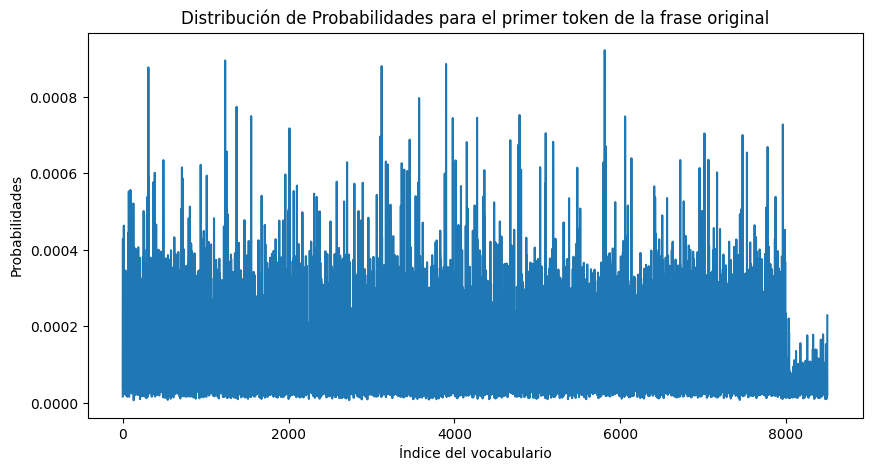

In [18]:
# ==================================================================
# Volver a testear con la frase original después del entrenamiento
# ==================================================================

# Convertimos la frase original en índices de nuevo
indexed_sentence = [vocab.get(word, 0) for word in tokens]  # Usamos 0 para palabras desconocidas
input_tensor = torch.tensor(indexed_sentence).unsqueeze(0)  # Añadir dimensión batch

# Creamos la máscara
src_mask = (input_tensor != 0).unsqueeze(1).unsqueeze(2)

# Obtenemos la predicción del modelo
model.eval()
with torch.no_grad():
    output = model(input_tensor, src_mask)

# Aplicamos softmax para convertir los logits en probabilidades
probabilities = softmax(output)

# Mostramos las probabilidades del primer token de la secuencia
plt.figure(figsize=(10, 5))
plt.plot(probabilities[0, 0].detach().numpy())
plt.title('Distribución de Probabilidades para el primer token de la frase original')
plt.xlabel('Índice del vocabulario')
plt.ylabel('Probabilidades')
plt.show()

Como estudiante de ingeniería y partidario de la socialdemocracia progresista, encuentro una interesante convergencia entre las ideas sociales de Noam Chomsky y las herramientas técnicas que estamos explorando en este curso de NLP. Los modelos de Transformers, en cierta manera un proceso democrático de transferencia y transformación de información. Así como Chomsky critica las jerarquías autoritarias en el capitalismo, estos modelos pueden interpretarse como una herramienta que permite procesar el lenguaje de manera más inclusiva, transformando el input en algo nuevo, con el potencial de devolver el control sobre la información a los usuarios.

Al aplicar esta tecnología, me resulta fundamental conectar estas innovaciones técnicas con una perspectiva social. La capacidad de los Transformers para manejar grandes volúmenes de texto y generar traducciones o resúmenes abre oportunidades para democratizar el acceso a la información, combatir la desinformación y crear sistemas más equitativos de participación. Así como Chomsky defiende la democratización de las instituciones económicas, considero que estas tecnologías deben usarse con un propósito social, garantizando que sean accesibles para todos y que su desarrollo promueva una participación inclusiva.

**Responda: ¿Qué es el posicional encoding? ¿Y por qué debe definirse una función para los transformer?**

El positional encoding lo usan los modelos Transformer para incorporar información sobre el orden de los tokens en una secuencia. Procesan los tokens de manera paralela. No tienen una estructura interna para entender el orden de los tokens, ya que cada token se procesa independientemente en cada capa de atención.

Para resolver este problema, se utiliza el positional encoding para agregar información sobre la posición de cada token en la secuencia. Esta información se suma a los embeddings de las palabras antes de pasarlas a las capas de atención.

¿Por qué debe definirse una función de positional encoding?
Capturar la posición de los tokens: El modelo Transformer necesita entender el orden en el que aparecen los tokens, ya que no tiene una estructura interna secuencial como las RNNs. El positional encoding utiliza funciones seno y coseno para representar la posición de cada token en una secuencia.

Características de variabilidad: La función de positional encoding permite que cada posición de un token se represente de manera única mediante un patrón cíclico (seno para las posiciones pares y coseno para las impares). Esto asegura que el modelo no solo capture la identidad de cada palabra, sino también su posición en la secuencia.

No paramétrico y eficiente: El positional encoding no depende de parámetros que deban aprenderse durante el entrenamiento. Se calcula de forma determinística, lo que hace que el proceso sea eficiente y evita agregar más parámetros al modelo.